<a href="https://colab.research.google.com/github/amit809070/Object-Detection-Using-Iot-and-ML-To-avoid-Accidents/blob/main/Amit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Dataset Load and Splitting
california = fetch_california_housing()
X, y = california.data, california.target
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

# Scaling and Adding Bias
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]


In [11]:
# Normal Equation
theta_normal = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
y_pred_normal = X_test_bias @ theta_normal

# Gradient Descent Function
def gradient_descent(X, y, lr=0.05, epochs=2000):
    m, n = X.shape
    theta = np.zeros(n)
    for epoch in range(epochs):
        predictions = X @ theta
        errors = predictions - y
        gradient = (2 / m) * (X.T @ errors)
        theta -= lr * gradient
    return theta

theta_gd = gradient_descent(X_train_bias, y_train)
y_pred_gd = X_test_bias @ theta_gd


In [12]:
# Sklearn Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_sklearn = lr_model.predict(X_test_scaled)

# Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Lasso
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

In [13]:
models = {
    "Normal Equation (Scratch)": y_pred_normal,
    "Gradient Descent (Scratch)": y_pred_gd,
    "Linear Regression (Sklearn)": y_pred_sklearn,
    "Ridge Regression (Sklearn)": y_pred_ridge,
    "Lasso Regression (Sklearn)": y_pred_lasso
}

print(f"{'Model':<30} | {'MSE':<10} | {'R2 Score':<10}")
print("-" * 58)
for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name:<30} | {mse:<10.4f} | {r2:<10.4f}")

Model                          | MSE        | R2 Score  
----------------------------------------------------------
Normal Equation (Scratch)      | 0.5559     | 0.5758    
Gradient Descent (Scratch)     | 0.5559     | 0.5758    
Linear Regression (Sklearn)    | 0.5559     | 0.5758    
Ridge Regression (Sklearn)     | 0.5559     | 0.5758    
Lasso Regression (Sklearn)     | 0.5483     | 0.5816    


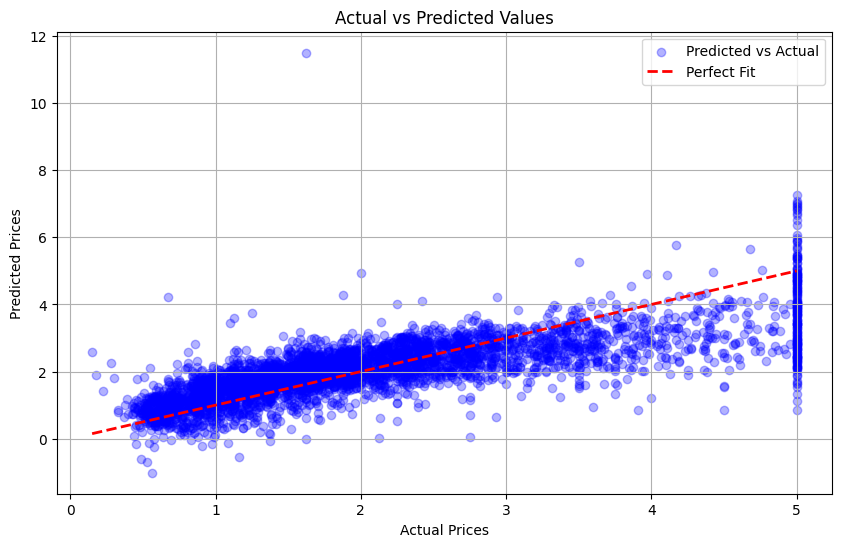

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_sklearn,alpha=0.3,  color='blue',label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()